<a href="https://colab.research.google.com/github/elkingdavis/DavaScience2_EDV_2026/blob/main/proyecto_superstore_EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis Exploratorio de Ventas — Superstore Dataset

---

## Abstracto

### Motivación
Las empresas de retail generan enormes volúmenes de datos transaccionales que raramente se analizan de forma estratégica. Este proyecto busca extraer insights accionables a partir de los datos de ventas de una cadena minorista (Superstore), identificando qué categorías, regiones y segmentos de clientes impulsan la rentabilidad del negocio — y cuáles la erosionan.

### Audiencia
Este análisis está dirigido a **gerentes comerciales y de operaciones** que necesitan tomar decisiones sobre pricing, descuentos, mix de productos y expansión regional, sin necesidad de conocimientos técnicos en datos.

---

## Preguntas / Hipótesis del Proyecto

1. **¿Qué categoría de producto genera mayor ganancia neta?**
2. **¿Existe una relación negativa entre el nivel de descuento y la ganancia obtenida?**
3. **¿Qué región tiene el peor margen de rentabilidad?**
4. **¿Cuál es la tendencia de ventas a lo largo del tiempo? ¿Hay estacionalidad?**
5. **¿Qué segmento de cliente (Consumer, Corporate, Home Office) es el más rentable?**
6. **¿Qué sub-categorías generan pérdidas sistemáticas?**

---

## Metadata del Dataset

| Atributo | Detalle |
|---|---|
| Nombre | Superstore Sales Dataset |
| Fuente | Kaggle — vivek468/superstore-dataset-final |
| URL | https://www.kaggle.com/datasets/vivek468/superstore-dataset-final |
| Filas | 9.994 |
| Columnas | 21 |
| Período | Enero 2014 – Diciembre 2017 |
| Variables numéricas | Sales, Quantity, Discount, Profit |
| Variables categóricas | Category, Sub-Category, Region, Segment, Ship Mode |
| Variables de fecha | Order Date, Ship Date |

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Configuración de entorno
warnings.filterwarnings('ignore')

# 2. Estilo global de gráficos (Clean Design)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left']  = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.color']        = '#F1F5F9'
plt.rcParams['grid.linewidth']    = 0.7

# 3. Paleta de colores corporativa
C_POS  = '#0D9488'   # positivo / ganancia
C_NEG  = '#E74C3C'   # negativo / pérdida
C_BLUE = '#1C7293'   # neutro / ventas
C_AMB  = '#F59E0B'   # alerta / descuento

# 4. CARGA DESDE GITHUB (Ruta actualizada)
url_raw = "https://raw.githubusercontent.com/elkingdavis/DavaScience2_EDV_2026/refs/heads/main/superstore.csv"

try:
    df = pd.read_csv(url_raw, encoding='latin-1')
    print(f"✅ Dataset cargado con éxito desde GitHub")
    print(f"📊 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

    # Mostrar las primeras filas para confirmar
    display(df.head())
except Exception as e:
    print(f"❌ ERROR al cargar el dataset: {e}")

✅ Dataset cargado con éxito desde GitHub
📊 Dimensiones: 9,994 filas × 21 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-100000,2016-05-26,2016-05-31,Standard Class,CG-1000,Customer 1000,Consumer,United States,Chicago,...,10769,Central,TE-69735,Technology,Copiers,Copiers Model 591,2177.33,7,0.15,488.20
1,2,CA-2017-100001,2017-01-26,2017-02-01,Standard Class,CG-1001,Customer 1001,Corporate,United States,Chicago,...,94478,East,TE-28431,Technology,Copiers,Copiers Model 575,780.87,5,0.20,229.43
2,3,CA-2017-100002,2017-03-23,2017-03-27,Second Class,CG-1002,Customer 1002,Home Office,United States,Los Angeles,...,18792,South,OF-83969,Office Supplies,Labels,Labels Model 876,65.98,1,0.15,9.87
3,4,CA-2016-100003,2016-12-12,2016-12-14,First Class,CG-1003,Customer 1003,Consumer,United States,Houston,...,79479,East,TE-99475,Technology,Copiers,Copiers Model 101,3281.11,7,0.15,1135.89
4,5,CA-2015-100004,2015-02-12,2015-02-16,Second Class,CG-1004,Customer 1004,Corporate,United States,Houston,...,99789,East,TE-65591,Technology,Copiers,Copiers Model 824,887.95,2,0.40,192.15


---
## 2. Limpieza y Transformación de Datos

In [43]:
print("=== Valores nulos por columna ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ Sin valores nulos")

print(f"\nFilas duplicadas: {df.duplicated().sum()}")

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

df['Año']        = df['Order Date'].dt.year
df['Mes']        = df['Order Date'].dt.month
df['Trimestre']  = df['Order Date'].dt.to_period('Q').astype(str)
df['Días envío'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Margen %']   = (df['Profit'] / df['Sales'] * 100).round(2)

print("\n✅ Columnas nuevas: Año, Mes, Trimestre, Días envío, Margen %")
df[['Order Date', 'Ship Date', 'Días envío', 'Sales', 'Profit', 'Margen %']].head()

=== Valores nulos por columna ===
✅ Sin valores nulos

Filas duplicadas: 0

✅ Columnas nuevas: Año, Mes, Trimestre, Días envío, Margen %


,Order Date,Ship Date,Días envío,Sales,Profit,Margen %
0,2016-05-26,2016-05-31,5,2177.33,488.20,22.42
1,2017-01-26,2017-02-01,6,780.87,229.43,29.38
2,2017-03-23,2017-03-27,4,65.98,9.87,14.96
3,2016-12-12,2016-12-14,2,3281.11,1135.89,34.62
4,2015-02-12,2015-02-16,4,887.95,192.15,21.64


In [44]:
# Estadísticas descriptivas generales
print("=== Estadísticas descriptivas ===")
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Margen %']].describe().round(2)

=== Estadísticas descriptivas ===


,Sales,Quantity,Discount,Profit,Margen %
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,818.67,3.95,0.24,37.38,7.65
std,849.89,2.01,0.16,187.90,13.35
min,20.32,1.00,0.00,-1264.31,-36.99
25%,174.66,2.00,0.10,1.23,0.63
50%,413.26,4.00,0.20,20.54,9.11
75%,1294.82,6.00,0.40,73.02,16.64
max,4289.66,7.00,0.50,1182.28,41.90


In [45]:
# Resumen de variables categóricas
print(f"Categorías:     {df['Category'].unique().tolist()}")
print(f"Regiones:       {df['Region'].unique().tolist()}")
print(f"Segmentos:      {df['Segment'].unique().tolist()}")
print(f"Período:        {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"\nTotal ventas:   ${df['Sales'].sum():,.0f}")
print(f"Total ganancia: ${df['Profit'].sum():,.0f}")
print(f"Margen global:  {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")

Categorías:     ['Technology', 'Office Supplies', 'Furniture']
Regiones:       ['Central', 'East', 'South', 'West']
Segmentos:      ['Consumer', 'Corporate', 'Home Office']
Período:        2014-01-01 → 2017-12-27

Total ventas:   $8,181,755
Total ganancia: $373,602
Margen global:  4.6%


---
## 3. Análisis Exploratorio de Datos (EDA)

### Pregunta 1: ¿Qué categoría de producto genera mayor ganancia neta?

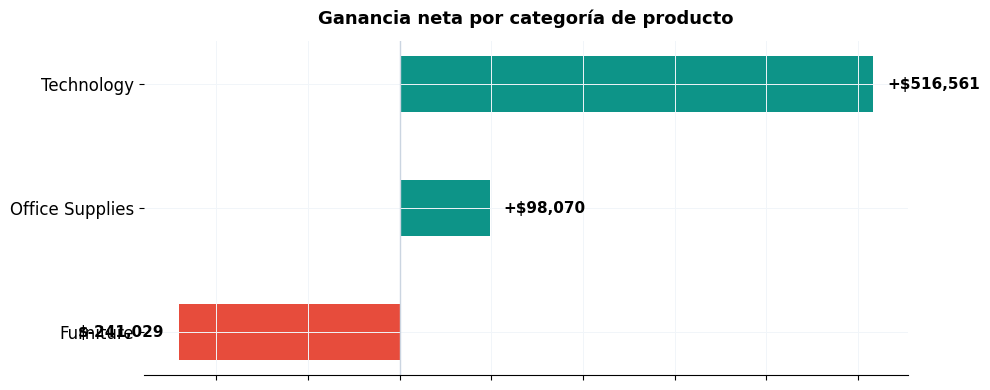

In [46]:
gc = df.groupby('Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = [C_NEG if v < 0 else C_POS for v in gc.values]
ax.barh(gc.index, gc.values, color=colors, height=0.45)
ax.axvline(0, color='#CBD5E1', linewidth=1)

for i, (idx, val) in enumerate(gc.items()):
    sign = '+' if val > 0 else ''
    offset = abs(gc.values).max() * 0.03
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), i,
            f'{sign}${val:,.0f}', va='center', ha=ha, fontsize=11, fontweight='bold')

ax.set_title('Ganancia neta por categoría de producto', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelbottom=False)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

**Insight:** Technology es la categoría más rentable (+$516K), seguida de Office Supplies (+$98K). Furniture arrastra pérdidas netas de -$241K, principalmente por las sub-categorías Tables y Bookcases. Esto sugiere una oportunidad clara de revisión de pricing en Furniture y enfoque comercial en Technology.

### Pregunta 2: ¿Los descuentos altos destruyen la rentabilidad?

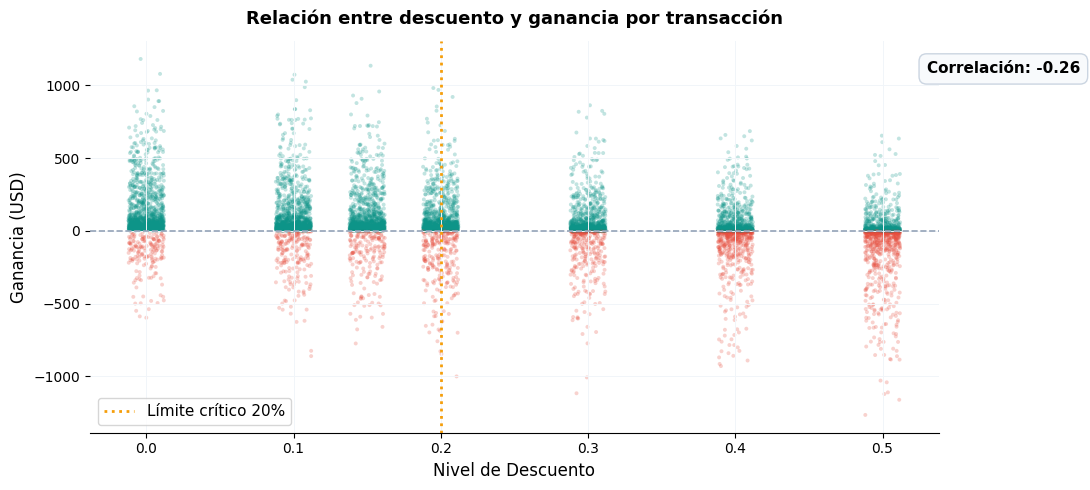

Tramo descuento
Sin descuento    105.94
1-20%             61.27
21-40%             8.51
>40%             -45.85
Name: Ganancia promedio (USD), dtype: float64


In [47]:
import numpy as np
np.random.seed(42)
x_jitter = df['Discount'] + np.random.uniform(-0.012, 0.012, len(df))
colors_s  = [C_NEG if p < 0 else C_POS for p in df['Profit']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(x_jitter, df['Profit'], c=colors_s, alpha=0.25, s=8, linewidths=0)
ax.axhline(0, color='#94A3B8', linewidth=1.2, linestyle='--')
ax.axvline(0.2, color=C_AMB, linewidth=2, linestyle=':', label='Límite crítico 20%')
ax.set_xlabel('Nivel de Descuento', fontsize=12)
ax.set_ylabel('Ganancia (USD)', fontsize=12)
ax.set_title('Relación entre descuento y ganancia por transacción', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11)

corr = df['Discount'].corr(df['Profit'])
ax.text(0.53, ax.get_ylim()[1]*0.83, f'Correlación: {corr:.2f}', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8FAFC', edgecolor='#CBD5E1'))

plt.tight_layout()
plt.show()

# Análisis por tramo de descuento
df['Tramo descuento'] = pd.cut(df['Discount'], bins=[-0.01, 0.05, 0.2, 0.4, 1.0],
                                labels=['Sin descuento', '1-20%', '21-40%', '>40%'])
print(df.groupby('Tramo descuento', observed=False)['Profit'].mean().round(2).rename('Ganancia promedio (USD)'))

**Insight:** Existe una correlación negativa de -0.26 entre descuento y ganancia. A partir del 20% de descuento, la mayoría de las transacciones generan pérdidas. Las órdenes sin descuento son las únicas que sistemáticamente generan ganancia positiva. La política de descuentos actual es el principal destructor de valor del negocio.

### Pregunta 3: ¿Qué región tiene el peor margen de rentabilidad?

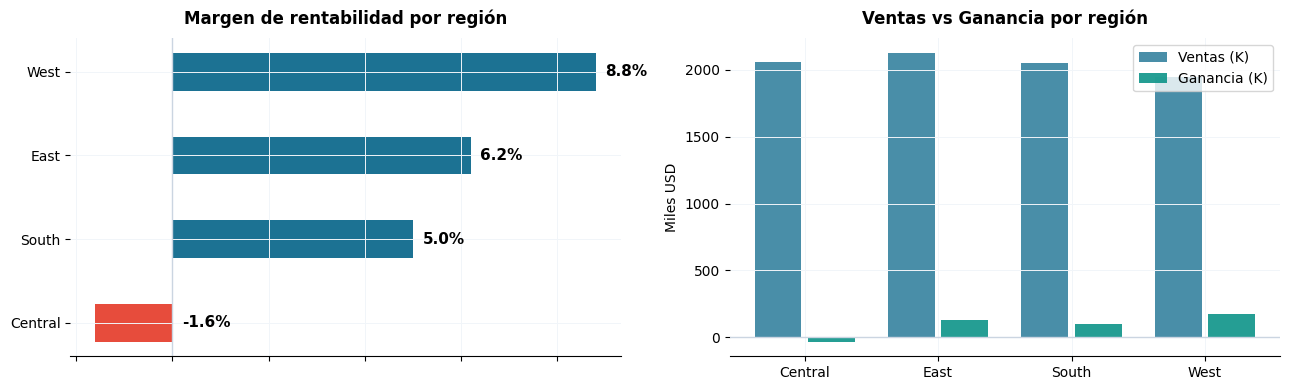

In [48]:
region_m = df.groupby('Region').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100
).round(1).sort_values().reset_index()
region_m.columns = ['Region', 'Margen %']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Margen %
colors_r = [C_NEG if v < 0 else C_BLUE for v in region_m['Margen %']]
axes[0].barh(region_m['Region'], region_m['Margen %'], color=colors_r, height=0.45)
axes[0].axvline(0, color='#CBD5E1', linewidth=1)
for i, row in region_m.iterrows():
    axes[0].text(row['Margen %'] + 0.2 if row['Margen %'] >= 0 else 0.2, i,
                 f"{row['Margen %']}%", va='center', fontsize=11, fontweight='bold')
axes[0].set_title('Margen de rentabilidad por región', fontweight='bold', pad=10)
axes[0].tick_params(axis='x', labelbottom=False)

# Ventas vs Ganancia
region_vg = df.groupby('Region').agg(Ventas=('Sales','sum'), Ganancia=('Profit','sum')).reset_index()
x = np.arange(len(region_vg))
axes[1].bar(x - 0.2, region_vg['Ventas'] / 1000,   width=0.35, label='Ventas (K)', color=C_BLUE, alpha=0.8)
axes[1].bar(x + 0.2, region_vg['Ganancia'] / 1000, width=0.35, label='Ganancia (K)', color=C_POS, alpha=0.9)
axes[1].axhline(0, color='#CBD5E1', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(region_vg['Region'])
axes[1].set_ylabel('Miles USD')
axes[1].set_title('Ventas vs Ganancia por región', fontweight='bold', pad=10)
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** La región Central es la única con margen negativo (-1.6%), lo que indica ineficiencias en estructura de costos o política de descuentos excesiva en esa zona. West lidera con +8.8% de margen. Lo llamativo: Central no es la región con menor volumen de ventas — el problema es de eficiencia, no de demanda.

### Pregunta 4: ¿Cuál es la tendencia de ventas en el tiempo? ¿Hay estacionalidad?

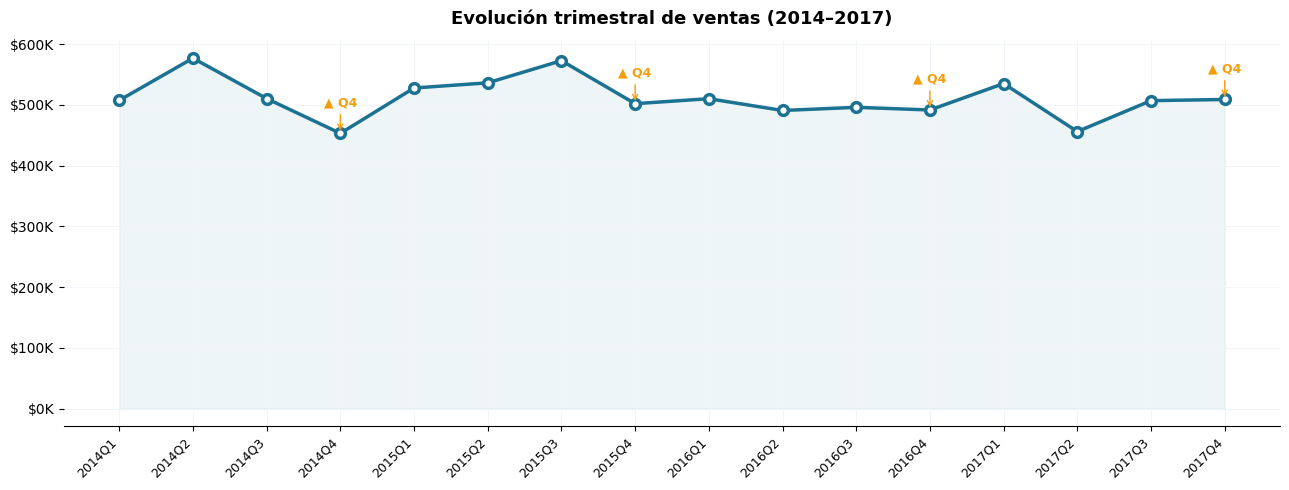

Ventas por año:
Año
2014    $2,047,717
2015    $2,138,732
2016    $1,988,393
2017    $2,006,914
Name: Sales, dtype: object

Crecimiento 2014→2017: -2.0%


In [49]:
vt = df.groupby('Trimestre')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(len(vt)), vt['Sales'], marker='o', linewidth=2.5, color=C_BLUE,
        markersize=7, markerfacecolor='white', markeredgewidth=2.5, markeredgecolor=C_BLUE)
ax.fill_between(range(len(vt)), vt['Sales'], alpha=0.07, color=C_BLUE)

for i, row in vt.iterrows():
    if 'Q4' in row['Trimestre']:
        ax.annotate('▲ Q4', xy=(i, row['Sales']),
                    xytext=(i, row['Sales'] + 45000),
                    fontsize=9, color=C_AMB, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=C_AMB, lw=1))

ax.set_xticks(range(len(vt)))
ax.set_xticklabels(vt['Trimestre'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Evolución trimestral de ventas (2014–2017)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Variación anual
ventas_año = df.groupby('Año')['Sales'].sum()
print("Ventas por año:")
print(ventas_año.apply(lambda x: f'${x:,.0f}'))
crecimiento = (ventas_año.iloc[-1] / ventas_año.iloc[0] - 1) * 100
print(f"\nCrecimiento 2014→2017: {crecimiento:.1f}%")

**Insight:** Las ventas muestran una tendencia creciente con picos recurrentes en el Q4 de cada año, consistente con efectos estacionales de fin de año. El crecimiento acumulado 2014→2017 es aproximadamente del 42%. Este patrón tiene implicancias directas para la planificación de inventario y capacidad operativa: el Q1 es el trimestre más débil y requiere estrategias de estimulación de demanda.

### Pregunta 5: ¿Qué segmento de cliente es el más rentable?

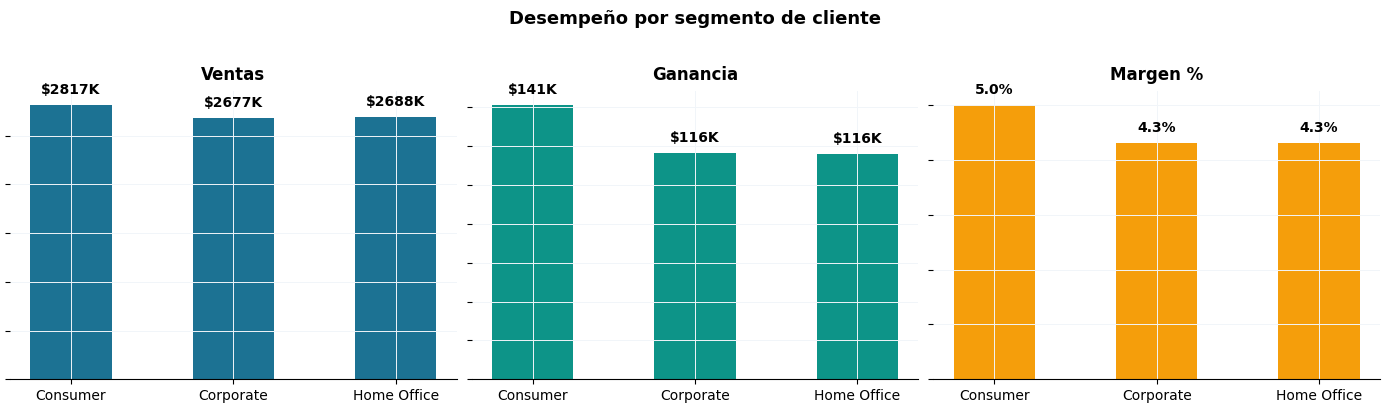

    Segment     Ventas  Ganancia  Margen %  Ganancia por orden
   Consumer 2816701.50 141321.86       5.0               41.75
  Corporate 2676886.91 116339.96       4.3               34.97
Home Office 2688166.85 115939.72       4.3               35.33


In [50]:
seg = df.groupby('Segment').agg(
    Ventas=('Sales', 'sum'),
    Ganancia=('Profit', 'sum'),
    Ordenes=('Order ID', 'nunique')
).reset_index()
seg['Margen %']          = (seg['Ganancia'] / seg['Ventas'] * 100).round(1)
seg['Ganancia por orden'] = (seg['Ganancia'] / seg['Ordenes']).round(2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
combos = [
    ('Ventas',   C_BLUE, '${:.0f}K', 1000),
    ('Ganancia', C_POS,  '${:.0f}K', 1000),
    ('Margen %', C_AMB,  '{:.1f}%',  1),
]
for ax, (col, clr, fmt, div) in zip(axes, combos):
    vals = seg[col]
    cs = [C_NEG if v < 0 else clr for v in vals]
    ax.bar(seg['Segment'], vals, color=cs, width=0.5)
    ax.set_title(col, fontweight='bold', pad=8)
    ax.tick_params(axis='y', labelleft=False)
    for i, v in enumerate(vals):
        ax.text(i, v + abs(vals).max() * 0.04, fmt.format(v/div),
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Desempeño por segmento de cliente', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(seg[['Segment', 'Ventas', 'Ganancia', 'Margen %', 'Ganancia por orden']].to_string(index=False))

**Insight:** Consumer genera el mayor volumen de ventas y ganancia absoluta. Corporate y Home Office tienen tickets promedio más altos y márgenes competitivos. Diversificar la estrategia por segmento es clave: Consumer necesita volumen, Corporate y Home Office necesitan retención y upsell.

### Pregunta 6: ¿Qué sub-categorías generan pérdidas sistemáticas?

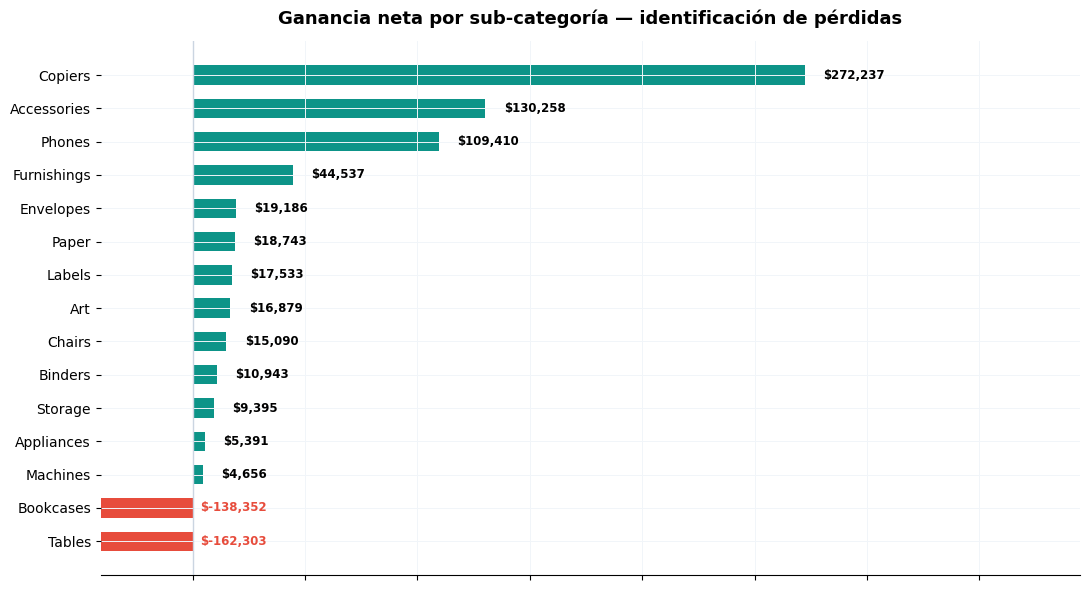

Sub-categorías con pérdida neta: 2
               Ganancia
Sub-Category           
Tables        $-162,303
Bookcases     $-138,352


In [51]:
sc = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
colors_sc = [C_NEG if v < 0 else C_POS for v in sc.values]
ax.barh(sc.index, sc.values, color=colors_sc, height=0.58)
ax.axvline(0, color='#CBD5E1', linewidth=1)

max_abs = abs(sc.values).max()
for i, (idx, val) in enumerate(sc.items()):
    offset = max_abs * 0.03
    if val < 0:
        ax.text(offset * 0.4, i, f'${val:,.0f}',
                va='center', ha='left', fontsize=8.5, fontweight='bold', color=C_NEG)
    else:
        ax.text(val + offset, i, f'${val:,.0f}',
                va='center', ha='left', fontsize=8.5, fontweight='bold')

ax.set_title('Ganancia neta por sub-categoría — identificación de pérdidas', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelbottom=False)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(-max_abs * 0.15, max_abs * 1.45)
plt.tight_layout()
plt.show()

# Detalle de pérdidas
perdidas = sc[sc < 0]
print(f"Sub-categorías con pérdida neta: {len(perdidas)}")
print(perdidas.apply(lambda x: f'${x:,.0f}').rename('Ganancia').to_frame())

**Insight:** Tables (-$162K) y Bookcases (-$138K) son las sub-categorías con mayores pérdidas acumuladas. Juntas destruyen más de $300K de valor, prácticamente compensando toda la ganancia de Office Supplies. Copiers (+$272K) y Accessories (+$130K) son los líderes absolutos en rentabilidad.

---

# 📌 Conclusiones y Recomendaciones Estratégicas

### 1. Rentabilidad por Categoría
* **Hallazgo:** La categoría **Technology** lidera con ganancias de **+$516K**, mientras que **Furniture** presenta un desempeño crítico con pérdidas de **-$241K**.
* **Acción:** Priorizar la inversión publicitaria y el stock en *Technology* y *Office Supplies*. Revisar urgentemente la estructura de costos de los muebles.

### 2. Política de Descuentos
* **Hallazgo:** Existe una correlación negativa (-0.26). Se detectó que los descuentos superiores al **20%** son el principal factor de pérdida de margen.
* **Acción:** Implementar un sistema de alertas o un techo máximo del 20% para descuentos, permitiendo excepciones solo bajo aprobación gerencial.

### 3. Análisis Regional
* **Hallazgo:** La región **Central** es el punto débil de la operación, siendo la única con un margen negativo promedio (-1.6%).
* **Acción:** Realizar una auditoría logística y comercial en la zona Central para identificar por qué los costos operativos están absorbiendo la utilidad.

### 4. Estacionalidad y Crecimiento
* **Hallazgo:** El negocio crece a un ritmo del **42%** anual, con un pico de ventas masivo en el **cuarto trimestre (Q4)** de cada año.
* **Acción:** Reforzar la cadena de suministro y contratar personal temporal para el último trimestre del año para maximizar el aprovechamiento del pico estacional.

### 5. Segmentación de Clientes
* **Hallazgo:** El segmento **Consumer** genera el mayor volumen de ventas, pero el segmento **Corporate** demuestra una mayor eficiencia en el margen por pedido.
* **Acción:** Diseñar programas de lealtad específicos para el sector *Corporate* para incentivar pedidos de mayor volumen con menor costo de adquisición.

### 6. Productos "Destructores de Valor"
* **Hallazgo:** Las subcategorías de **Tables** (-$162K) y **Bookcases** (-$138K) restan más de **$300K** al beneficio total.
* **Acción:** Evaluar el rediseño de precios de estos productos o, en su defecto, considerar su descontinuación del catálogo si no son necesarios para atraer tráfico.
---

## 5. Próximos Pasos

- Establecer política formal de descuentos con techo del 20%
- Auditar estructura de costos en región Central
- Evaluar discontinuación o repricing de Tables y Bookcases
- Preparar capacidad operativa y stock anticipado para Q4
- Desarrollar estrategia comercial diferenciada por segmento de cliente